In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
import pandas as pd

In [22]:
df =  pd.read_csv('/content/drive/MyDrive/Churn_Modelling.csv')

In [23]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [24]:
df.drop(columns=['RowNumber',	'CustomerId',	'Surname'],inplace=True)

In [25]:
df.head(1)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.0,1,1,1,101348.88,1


In [26]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [27]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [28]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'],drop_first=True)

In [29]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [30]:
X = df.drop(columns=['Exited'])

In [31]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [32]:
y = df['Exited'].values

In [33]:
y

array([1, 0, 1, ..., 1, 1, 0])

In [34]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
X_train

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
7389,667,34,5,0.00,2,1,0,163830.64,False,True,False
9275,427,42,1,75681.52,1,1,1,57098.00,True,False,True
2995,535,29,2,112367.34,1,1,0,185630.76,False,False,False
5316,654,40,5,105683.63,1,1,0,173617.09,False,True,True
356,850,57,8,126776.30,2,1,1,132298.49,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9225,594,32,4,120074.97,2,1,1,162961.79,True,False,False
4859,794,22,4,114440.24,1,1,1,107753.07,False,True,False
3264,738,35,5,161274.05,2,1,0,181429.87,False,False,True
9845,590,38,9,0.00,2,1,1,148750.16,False,True,False


In [37]:
y_train

array([0, 0, 0, ..., 0, 0, 1])

In [38]:
X_test

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
9394,597,35,8,131101.04,1,1,1,192852.67,True,False,False
898,523,40,2,102967.41,1,1,0,128702.10,False,False,False
2398,706,42,8,95386.82,1,1,1,75732.25,False,True,False
5906,788,32,4,112079.58,1,0,0,89368.59,False,False,True
2343,706,38,5,163034.82,2,1,1,135662.17,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...
1037,625,24,1,0.00,2,1,1,180969.55,False,False,False
2899,586,35,7,0.00,2,1,0,70760.69,False,False,False
9549,578,36,1,157267.95,2,1,0,141533.19,False,True,True
2740,650,34,4,142393.11,1,1,1,11276.48,True,False,True


In [43]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [44]:
model = Sequential()

In [46]:
model.add(Dense(11,activation='sigmoid', input_dim=11))
model.add(Dense(11,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
model.compile(optimizer='Adam', loss = 'binary_crossentropy', metrics=['accuracy'])

In [49]:
history = model.fit(X_train,y_train,batch_size=50,epochs=50,verbose=1,validation_split=0.2)

Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7344 - loss: 0.5874 - val_accuracy: 0.7969 - val_loss: 0.5145
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7958 - loss: 0.5074 - val_accuracy: 0.7969 - val_loss: 0.5031
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7958 - loss: 0.5045 - val_accuracy: 0.7969 - val_loss: 0.5021
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7958 - loss: 0.5040 - val_accuracy: 0.7969 - val_loss: 0.5013
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7958 - loss: 0.5036 - val_accuracy: 0.7969 - val_loss: 0.5006
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7958 - loss: 0.5032 - val_accuracy: 0.7969 - val_loss: 0.5001
Epoch 7/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7958 - loss: 0.5030 - val_accuracy: 0.7969 - val_loss: 0.4996
Epoch 8/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7958 - loss: 0.5027 - val_accuracy: 0.

In [50]:
y_pred = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [51]:
y_pred

array([[0.24715948],
       [0.24715948],
       [0.24715948],
       ...,
       [0.24715948],
       [0.23392093],
       [0.24715948]], dtype=float32)

In [52]:
y_pred = y_pred.argmax(axis=-1)

In [53]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7975

In [55]:
model.get_weights()[0]

array([[-0.43121436,  0.48906308,  0.21627477,  0.1821656 ,  0.48222393,
        -0.25250524,  0.18554963,  0.26308006,  0.33355653,  0.1812598 ,
         0.17453042],
       [-0.4582601 , -0.5183409 ,  0.5932136 ,  0.0921409 , -0.13089517,
         0.15045118,  0.37064013, -0.19004606, -0.20681664, -0.1666379 ,
        -0.42647377],
       [ 0.01008332, -0.05129403,  0.28791726, -0.06141443,  0.23473626,
         0.4000907 ,  0.07925785, -0.33370537,  0.04852778, -0.12474182,
         0.21988936],
       [ 0.12451726,  0.4909634 ,  0.2534813 , -0.19252637,  0.08588517,
        -0.38675082, -0.38835055, -0.49473378,  0.01414096, -0.06688705,
        -0.24536051],
       [-0.24998747,  0.29452342, -0.2588442 , -0.26553014, -0.17861575,
        -0.14529637, -0.31954423, -0.05983837,  0.2767614 ,  0.09184255,
         0.16867144],
       [-0.13888973, -0.47858733,  0.64418876,  0.50042164, -0.38945085,
         0.50320905, -0.18159868, -0.405431  , -0.3200772 ,  0.1836816 ,
         0.198

In [59]:
len(model.get_weights()[0])

11

In [58]:
model.get_weights()[1]

array([ 0.01021049,  0.        ,  0.18425374,  0.00699088,  0.        ,
        0.        ,  0.1278687 ,  0.01147301,  0.        , -0.03557215,
        0.00284353], dtype=float32)

In [63]:
layer1 = model.layers[0]

In [64]:
w1 , b1 = layer1.get_weights()

In [65]:
w1

array([[-0.43121436,  0.48906308,  0.21627477,  0.1821656 ,  0.48222393,
        -0.25250524,  0.18554963,  0.26308006,  0.33355653,  0.1812598 ,
         0.17453042],
       [-0.4582601 , -0.5183409 ,  0.5932136 ,  0.0921409 , -0.13089517,
         0.15045118,  0.37064013, -0.19004606, -0.20681664, -0.1666379 ,
        -0.42647377],
       [ 0.01008332, -0.05129403,  0.28791726, -0.06141443,  0.23473626,
         0.4000907 ,  0.07925785, -0.33370537,  0.04852778, -0.12474182,
         0.21988936],
       [ 0.12451726,  0.4909634 ,  0.2534813 , -0.19252637,  0.08588517,
        -0.38675082, -0.38835055, -0.49473378,  0.01414096, -0.06688705,
        -0.24536051],
       [-0.24998747,  0.29452342, -0.2588442 , -0.26553014, -0.17861575,
        -0.14529637, -0.31954423, -0.05983837,  0.2767614 ,  0.09184255,
         0.16867144],
       [-0.13888973, -0.47858733,  0.64418876,  0.50042164, -0.38945085,
         0.50320905, -0.18159868, -0.405431  , -0.3200772 ,  0.1836816 ,
         0.198

In [66]:
b1

array([ 0.01021049,  0.        ,  0.18425374,  0.00699088,  0.        ,
        0.        ,  0.1278687 ,  0.01147301,  0.        , -0.03557215,
        0.00284353], dtype=float32)

In [67]:
layer2 = model.layers[1]

In [68]:
w2 , b2 = layer1.get_weights()

In [69]:
w2

array([[-0.43121436,  0.48906308,  0.21627477,  0.1821656 ,  0.48222393,
        -0.25250524,  0.18554963,  0.26308006,  0.33355653,  0.1812598 ,
         0.17453042],
       [-0.4582601 , -0.5183409 ,  0.5932136 ,  0.0921409 , -0.13089517,
         0.15045118,  0.37064013, -0.19004606, -0.20681664, -0.1666379 ,
        -0.42647377],
       [ 0.01008332, -0.05129403,  0.28791726, -0.06141443,  0.23473626,
         0.4000907 ,  0.07925785, -0.33370537,  0.04852778, -0.12474182,
         0.21988936],
       [ 0.12451726,  0.4909634 ,  0.2534813 , -0.19252637,  0.08588517,
        -0.38675082, -0.38835055, -0.49473378,  0.01414096, -0.06688705,
        -0.24536051],
       [-0.24998747,  0.29452342, -0.2588442 , -0.26553014, -0.17861575,
        -0.14529637, -0.31954423, -0.05983837,  0.2767614 ,  0.09184255,
         0.16867144],
       [-0.13888973, -0.47858733,  0.64418876,  0.50042164, -0.38945085,
         0.50320905, -0.18159868, -0.405431  , -0.3200772 ,  0.1836816 ,
         0.198

In [70]:
b2

array([ 0.01021049,  0.        ,  0.18425374,  0.00699088,  0.        ,
        0.        ,  0.1278687 ,  0.01147301,  0.        , -0.03557215,
        0.00284353], dtype=float32)

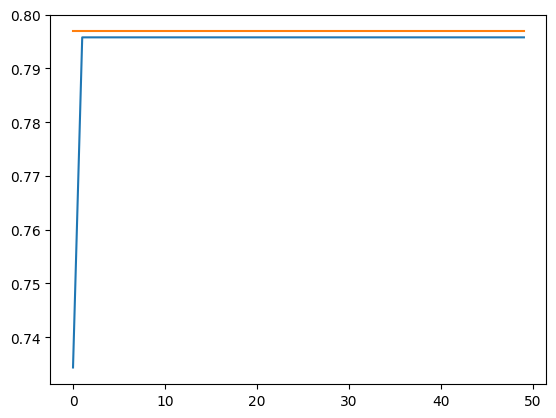

In [71]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])